# **ANOMALY DETECTION WITH LSTM AUTOENCODER**


## **Problem Statement**
Financial markets are highly dynamic and influenced by numerous factors, including macroeconomic indicators, investor sentiment, and global events. Detecting anomalies in stock prices is essential for uncovering unusual patterns that may signal market manipulation, financial fraud, or rare investment opportunities.

In this project, I applied a Long Short-Term Memory (LSTM) autoencoder to reconstruct stock price **log returns**, which is better than the absolute stock prices at identifying unusual relative movements due to additivity and normalization features. If the model struggles to accurately reconstruct a sequence (i.e., produces a large reconstruction error), the sequence likely contains anomalous behavior. Anomalies are flagged when the deviation between the actual and reconstructed log return exceeds the rolling threshold (i.e. rolling mean + rolling standard deviation of the reconstruction error). This thresholding strategy highlights only the most unusual price movements. LSTMs were chosen because they effectively model long-term temporal dependencies while balancing the need to forget outdated information and incorporate new patterns.

The results demonstrate that this approach can be valuable for traders, analysts, and financial institutions seeking to: i) identify arbitrage opportunities, ii) enhance risk management strategies, and iii) detect market irregularities in real time. Beyond finance, this anomaly detection framework generalizes to domains such as machine sensors, cybersecurity, and healthcare.

### **(1) Fetch Real Stock Price Data**
Download the adjusted stock prices of Tesla from Yahoo Finance since 2015.

In [ ]:
# install yfinance
!pip install yfinance

In [ ]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
import datetime

# Import Machine Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Import Automation & Pipeline libraries
import joblib
import os
import gc
import plotly.graph_objects as go

# Create directories to store production files
os.makedirs('models', exist_ok=True)
os.makedirs('scalers', exist_ok=True)

print("Libraries loaded and directories created successfully!")

Libraries loaded and directories created successfully!


In [ ]:
import datetime

# Define Global Pipeline Parameters
tickers = ['TSLA', 'GOOGL', 'NVDA', 'META'] # big tech companies
start_date = "2015-01-01"
end_date = datetime.date.today().isoformat() # date of today
time_step = 30 # 30-day window for prediction
train_split = 0.7 # 70% of data is training date and 30% is test data

In [ ]:
# Download the adjusted stock prices from 2015 to the current stock price from Yahoo Finance
# and calculate the log returns

df_prices = {}

for ticker in tickers:
  # Initialize DataFrame for the current ticker
  df_prices[ticker] = pd.DataFrame()

  # Download stock prices
  stock_prices = yf.download(ticker, start_date, end_date, progress = False, auto_adjust=True)

  # Drop the "Ticker" level if it exists (for multi-level columns)
  stock_prices.columns = stock_prices.columns.droplevel(1)

  # Reset index to make 'Date' a regular column
  stock_prices = stock_prices.reset_index()

  # Calculate Log Return
  stock_prices["Log_Return"] = np.log(stock_prices["Close"] / stock_prices["Close"].shift(1))
  # Fill the first NaN (due to shift) with 0. This is a common practice for the first return.
  #stock_prices["Log_Return"].fillna(0, inplace=True)
  stock_prices.fillna({"Log_Return": 0}, inplace=True)

  # Assign Date, Close, Ticker, and Log_Return to df_prices[ticker]
  df_prices[ticker]["Date"] = stock_prices["Date"]
  df_prices[ticker]["Close"] = stock_prices["Close"]
  df_prices[ticker]["Ticker"] = ticker
  df_prices[ticker]["Log_Return"] = stock_prices["Log_Return"]


  print(f"DataFrame for {ticker} after log return calculation:")
  print(df_prices[ticker].head()) # Print head to show new Log_Return column

DataFrame for TSLA after log return calculation:
        Date      Close Ticker  Log_Return
0 2015-01-02  14.620667   TSLA    0.000000
1 2015-01-05  14.006000   TSLA   -0.042950
2 2015-01-06  14.085333   TSLA    0.005648
3 2015-01-07  14.063333   TSLA   -0.001563
4 2015-01-08  14.041333   TSLA   -0.001566
DataFrame for GOOGL after log return calculation:
        Date      Close Ticker  Log_Return
0 2015-01-02  26.260460  GOOGL    0.000000
1 2015-01-05  25.760092  GOOGL   -0.019238
2 2015-01-06  25.124350  GOOGL   -0.024989
3 2015-01-07  25.050461  GOOGL   -0.002945
4 2015-01-08  25.137737  GOOGL    0.003478
DataFrame for NVDA after log return calculation:
        Date     Close Ticker  Log_Return
0 2015-01-02  0.482985   NVDA    0.000000
1 2015-01-05  0.474828   NVDA   -0.017034
2 2015-01-06  0.460432   NVDA   -0.030788
3 2015-01-07  0.459232   NVDA   -0.002609
4 2015-01-08  0.476507   NVDA    0.036927
DataFrame for META after log return calculation:
        Date      Close Ticker  Log

### **(2) Data Preprocessing**
The below extracts the log returns from a dataset and splits them into training (70%) and test (30%) sets. It then uses a MinMaxScaler to normalize the data into the range [0, 1], fitting the scaler only on the training set to avoid data leakage, and applying the same transformation to the test set for consistency.

In [ ]:
# Get the log returns in 2-D array for model training

returns = {}

for ticker in tickers:
  returns[ticker] = df_prices[ticker][['Log_Return']].values
  print(f"Log Returns for {ticker}:")
  print(returns[ticker][:5]) # Print first 5 to verify

Log Returns for TSLA:
[[ 0.        ]
 [-0.04295033]
 [ 0.00564826]
 [-0.00156315]
 [-0.00156553]]
Log Returns for GOOGL:
[[ 0.        ]
 [-0.01923792]
 [-0.02498898]
 [-0.00294526]
 [ 0.00347797]]
Log Returns for NVDA:
[[ 0.        ]
 [-0.01703418]
 [-0.03078757]
 [-0.00260918]
 [ 0.03692747]]
Log Returns for META:
[[ 0.        ]
 [-0.01619119]
 [-0.01356509]
 [ 0.        ]
 [ 0.02630884]]


In [ ]:
# Split the dataset into training and test data at a ratio of 7:3
split = {}
train = {}
test = {}
for ticker in tickers:
  split[ticker] = int(len(returns[ticker]) * 0.7)
  train[ticker], test[ticker] = returns[ticker][:split[ticker]], returns[ticker][split[ticker]:]
  print("Shape of Training Set of " + ticker, train[ticker].shape)
  print("Shape of Test Set of " + ticker, test[ticker].shape)

Shape of Training Set of TSLA (2008, 1)
Shape of Test Set of TSLA (861, 1)
Shape of Training Set of GOOGL (2008, 1)
Shape of Test Set of GOOGL (861, 1)
Shape of Training Set of NVDA (2008, 1)
Shape of Test Set of NVDA (861, 1)
Shape of Training Set of META (2008, 1)
Shape of Test Set of META (861, 1)


In [ ]:
# Normalize all prices to value between 0 and 1
scalers = {}

train_scaled = {}
test_scaled = {}

for ticker in tickers:
    # Fit scaler on training data
    scalers[ticker] = MinMaxScaler()
    train_scaled[ticker] = scalers[ticker].fit_transform(train[ticker])
    # Apply the same scaler to test data
    test_scaled[ticker] = scalers[ticker].transform(test[ticker])

### **(3) Create Sequences with Timestep**
Define a time window of 30 timesteps, as the model will look at the past 30 days of log returns to predict the next one. The training and test sets are transformed into sequences (X_train, X_test) and corresponding targets (y_train, y_test). The input arrays are reshaped into 3D format (samples, time_steps, features), which is the required input shape for LSTM networks.

In [ ]:
# Initialize empty dictionaries to hold training and testing sequences + targets for each ticker
X_train_dict = {}
y_train_dict = {}
X_test_dict = {}
y_test_dict = {}

# Set the time window (number of past steps the LSTM will "look back" to predict/reconstruct)
time_step = 30  # The model will use the previous 30 time steps to learn/reconstruct

for ticker in tickers:
    X_train = []
    y_train = []
    X_test = []
    y_test = []

    # Loop through the training dataset for the current ticker
    for i in range(time_step, len(train_scaled[ticker])):
        # Take a sliding window of the previous 'time_step' values as input (features)
        X_train.append(train_scaled[ticker][i-time_step:i, 0])
        # Take the current value (at time i) as the target (label)
        y_train.append(train_scaled[ticker][i, 0])

    # Same applied for the test data for the current ticker
    for i in range(time_step, len(test_scaled[ticker])):
        X_test.append(test_scaled[ticker][i-time_step:i, 0])
        y_test.append(test_scaled[ticker][i, 0])

    X_train_dict[ticker] = np.asarray(X_train)
    y_train_dict[ticker] = np.asarray(y_train)
    X_test_dict[ticker] = np.asarray(X_test)
    y_test_dict[ticker] = np.asarray(y_test)

In [ ]:
# Reshape the arrays to 3D arrays for feeding into the LSTM model for each ticker
X_train_reshaped = {}
X_test_reshaped = {}

for ticker in tickers:
    X_train_reshaped[ticker] = np.reshape(X_train_dict[ticker], (X_train_dict[ticker].shape[0], X_train_dict[ticker].shape[1], 1))
    X_test_reshaped[ticker] = np.reshape(X_test_dict[ticker], (X_test_dict[ticker].shape[0], X_test_dict[ticker].shape[1], 1))
    print(f"Shape of X_train for {ticker}: {X_train_reshaped[ticker].shape}")
    print(f"Shape of X_test for {ticker}: {X_test_reshaped[ticker].shape}")

Shape of X_train for TSLA: (1978, 30, 1)
Shape of X_test for TSLA: (831, 30, 1)
Shape of X_train for GOOGL: (1978, 30, 1)
Shape of X_test for GOOGL: (831, 30, 1)
Shape of X_train for NVDA: (1978, 30, 1)
Shape of X_test for NVDA: (831, 30, 1)
Shape of X_train for META: (1978, 30, 1)
Shape of X_test for META: (831, 30, 1)


### **(4) Build LSTM Autoencoder**

In [ ]:
def build_autoencoder(input_shape):
    # T and F are now derived from the input_shape
    T = input_shape[0]  # no. of timesteps
    F = input_shape[1]  # no. of features

    # ---------- Input Layer ----------
    inputs = keras.layers.Input(shape=(T, F))

    # ---------- Encoder ----------
    x = keras.layers.LSTM(64, return_sequences=True)(inputs)
    x = keras.layers.Dropout(0.4)(x)
    x = keras.layers.LSTM(32, return_sequences=False)(x)
    x = keras.layers.Dropout(0.4)(x)

    # ---------- Decoder ----------
    x = keras.layers.RepeatVector(T)(x)
    x = keras.layers.LSTM(64, return_sequences=True)(x)
    x = keras.layers.Dropout(0.4)(x)
    x = keras.layers.LSTM(32, return_sequences=True)(x)
    x = keras.layers.Dropout(0.4)(x)

    # ---------- Output Layer ----------
    outputs = keras.layers.TimeDistributed(
        keras.layers.Dense(F, activation='linear')
    )(x)

    autoencoder = keras.Model(inputs=inputs, outputs=outputs)
    autoencoder.compile(optimizer='adam', loss='mae')  # MAE is common for recon error
    return autoencoder

autoencoders = {}
for ticker in tickers:
    # Get input shape from the reshaped training data for the current ticker
    input_shape = (X_train_reshaped[ticker].shape[1], X_train_reshaped[ticker].shape[2])
    autoencoders[ticker] = build_autoencoder(input_shape)
    print(f"Model summary for {ticker}:")
    autoencoders[ticker].summary()

Model summary for TSLA:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,593 (260.13 KB)

 Trainable params: 66,593 (260.13 KB)

...

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_7 (RepeatVector)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 30, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,593 (260.13 KB)

 Trainable params: 66,593 (260.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Condition for early stopping the model training
es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_dict = {}

for ticker in tickers:
    print(f"\nTraining autoencoder for {ticker}...")
    history = autoencoders[ticker].fit(
        X_train_reshaped[ticker], X_train_reshaped[ticker], # reconstruct the input
        epochs=30,
        batch_size=64,
        validation_split=0.1,
        shuffle=False,
        callbacks=[es],
        #verbose=0 # Set verbose to 0 to suppress output for each epoch
    )
    history_dict[ticker] = history
    print(f"Training for {ticker} completed. Best validation loss: {min(history.history['val_loss']):.4f}")


Training autoencoder for TSLA...
Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - loss: 0.2633 - val_loss: 0.1307
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.1509 - val_loss: 0.1062
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.1279 - val_loss: 0.1019
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.1159 - val_loss: 0.0990
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.1070 - val_loss: 0.0916
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.1005 - val_loss: 0.0894
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0953 - val_loss: 0.0840
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0911 - val_loss: 0.0824
Epoch 9/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0879 - val_loss: 0.0784
Epoch 10/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0854 - val_loss: 0.0786
Epoch 11/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0839 - val_loss: 0.0772
Epoch 12/30
28/28 ━━━━━━━

### **(5) Reconstructing Data Sequences**
The trained autoencoder is used to reconstruct both the training and test sequences. Predictions on X_train (predicted_train) and X_test (predicted_test) produce outputs with the same shape as the inputs.

In [ ]:
for ticker in tickers:
    print(f"Shape of X_train_reshaped for {ticker}: {X_train_reshaped[ticker].shape}")

Shape of X_train_reshaped for TSLA: (1978, 30, 1)
Shape of X_train_reshaped for GOOGL: (1978, 30, 1)
Shape of X_train_reshaped for NVDA: (1978, 30, 1)
Shape of X_train_reshaped for META: (1978, 30, 1)


In [ ]:
predicted_train_dict = {}

for ticker in tickers:
    # Use the trained autoencoder to reconstruct the training sequences
    # The output will have the same shape as the input (X_train_reshaped)
    predicted_train_dict[ticker] = autoencoders[ticker].predict(X_train_reshaped[ticker], verbose=0)
    print(f"Shape of predicted_train for {ticker}: {predicted_train_dict[ticker].shape}")

Shape of predicted_train for TSLA: (1978, 30, 1)
Shape of predicted_train for GOOGL: (1978, 30, 1)
Shape of predicted_train for NVDA: (1978, 30, 1)
Shape of predicted_train for META: (1978, 30, 1)


In [ ]:
for ticker in tickers:
    print(f"Shape of X_test_reshaped for {ticker}: {X_test_reshaped[ticker].shape}")

Shape of X_test_reshaped for TSLA: (831, 30, 1)
Shape of X_test_reshaped for GOOGL: (831, 30, 1)
Shape of X_test_reshaped for NVDA: (831, 30, 1)
Shape of X_test_reshaped for META: (831, 30, 1)


In [ ]:
predicted_test_dict = {}

for ticker in tickers:
    # Reconstruct the test set
    predicted_test_dict[ticker] = autoencoders[ticker].predict(X_test_reshaped[ticker], verbose=0)
    print(f"Shape of predicted_test for {ticker}: {predicted_test_dict[ticker].shape}")

Shape of predicted_test for TSLA: (831, 30, 1)
Shape of predicted_test for GOOGL: (831, 30, 1)
Shape of predicted_test for NVDA: (831, 30, 1)
Shape of predicted_test for META: (831, 30, 1)


### **(6) Detecting Anomalies with Rolling Mean Threshold**

To make the anomaly detection more adaptive to changing data patterns, I use a rolling mean plus a certain multiple of the rolling standard deviation of the reconstruction error (MAE) to define a dynamic threshold. This approach flags an anomaly if the current `MAE_Loss` of the test data exceeds that dynamic threshold.


In [ ]:
train_mae_loss_dict = {}

for ticker in tickers:
    # Per-window reconstruction error (MAE across time and feature) of the training data
    train_mae_loss_dict[ticker] = np.mean(np.abs(predicted_train_dict[ticker] - X_train_reshaped[ticker]), axis=(1,2))

In [ ]:
test_mae_loss_dict = {}

for ticker in tickers:
    # Reconstruction error (MAE) of test data
    test_mae_loss_dict[ticker] = np.mean(np.abs(predicted_test_dict[ticker] - X_test_reshaped[ticker]), axis=(1, 2))
    print(f"Calculated test MAE loss for {ticker}.")

Calculated test MAE loss for TSLA.
Calculated test MAE loss for GOOGL.
Calculated test MAE loss for NVDA.
Calculated test MAE loss for META.


In [ ]:
# Define the window size for the rolling calculation (e.g., using the same time_step) and a multiplier for std dev
rolling_window = time_step
num_std_dev = 2  # Multiplier for standard deviation (e.g., 2 for a 2-sigma threshold)

rolling_anomaly_dict = {}

for ticker in tickers:
    # Create a copy of the test_anomaly_df for rolling threshold analysis
    temp_df = df_prices[ticker].iloc[split[ticker]+time_step:].copy()

    # Calculate rolling mean and standard deviation of MAE_Loss
    temp_df['MAE_Loss'] = test_mae_loss_dict[ticker]
    temp_df['Rolling_Mean_MAE'] = temp_df['MAE_Loss'].rolling(window=rolling_window, min_periods=1).mean()
    temp_df['Rolling_Std_MAE'] = temp_df['MAE_Loss'].rolling(window=rolling_window, min_periods=1).std()

    # Define the dynamic threshold
    # Use .fillna(0) for Rolling_Std_MAE in the initial periods where std is NaN
    temp_df['Dynamic_Threshold'] = temp_df['Rolling_Mean_MAE'] + num_std_dev * temp_df['Rolling_Std_MAE'].fillna(0)

    # Anomaly is detected if MAE_Loss > Dynamic_Threshold
    temp_df['Rolling_Anomaly'] = temp_df['MAE_Loss'] > temp_df['Dynamic_Threshold']

    rolling_anomaly_dict[ticker] = temp_df
    print(f"Rolling mean anomaly results for {ticker}:")
    display(rolling_anomaly_dict[ticker].head())

# Extract anomalies detected by the rolling threshold for plotting
rolling_anomalies_for_plot_dict = {}
for ticker in tickers:
    rolling_anomalies_for_plot_dict[ticker] = rolling_anomaly_dict[ticker].loc[rolling_anomaly_dict[ticker]['Rolling_Anomaly'] == True]

Rolling mean anomaly results for TSLA:


,Date,Close,Ticker,Log_Return,MAE_Loss,Rolling_Mean_MAE,Rolling_Std_MAE,Dynamic_Threshold,Rolling_Anomaly
2038,2023-02-07,196.809998,TSLA,0.010471,0.105911,0.105911,NaN,0.105911,False
2039,2023-02-08,201.289993,TSLA,0.022508,0.098760,0.102335,0.005056,0.112448,False
2040,2023-02-09,207.320007,TSLA,0.029517,0.098509,0.101060,0.004203,0.109465,False
2041,2023-02-10,196.889999,TSLA,-0.051618,0.092341,0.098880,0.005548,0.109976,False
2042,2023-02-13,194.639999,TSLA,-0.011493,0.094397,0.097984,0.005206,0.108396,False


Rolling mean anomaly results for GOOGL:


,Date,Close,Ticker,Log_Return,MAE_Loss,Rolling_Mean_MAE,Rolling_Std_MAE,Dynamic_Threshold,Rolling_Anomaly
2038,2023-02-07,106.757660,GOOGL,0.045035,0.101533,0.101533,NaN,0.101533,False
2039,2023-02-08,98.555450,GOOGL,-0.079942,0.107888,0.104710,0.004493,0.113697,False
2040,2023-02-09,94.231186,GOOGL,-0.044868,0.114890,0.108104,0.006681,0.121466,False
2041,2023-02-10,93.794792,GOOGL,-0.004642,0.122686,0.111749,0.009106,0.129961,False
2042,2023-02-13,93.834465,GOOGL,0.000423,0.124695,0.114338,0.009783,0.133905,False


Rolling mean anomaly results for NVDA:


,Date,Close,Ticker,Log_Return,MAE_Loss,Rolling_Mean_MAE,Rolling_Std_MAE,Dynamic_Threshold,Rolling_Anomaly
2038,2023-02-07,22.149622,NVDA,0.050123,0.100734,0.100734,NaN,0.100734,False
2039,2023-02-08,22.181593,NVDA,0.001442,0.108084,0.104409,0.005197,0.114804,False
2040,2023-02-09,22.313456,NVDA,0.005927,0.108695,0.105838,0.004430,0.114699,False
2041,2023-02-10,21.242586,NVDA,-0.049182,0.114416,0.107982,0.005611,0.119204,False
2042,2023-02-13,21.765028,NVDA,0.024297,0.118375,0.110061,0.006724,0.123509,False


Rolling mean anomaly results for META:


,Date,Close,Ticker,Log_Return,MAE_Loss,Rolling_Mean_MAE,Rolling_Std_MAE,Dynamic_Threshold,Rolling_Anomaly
2038,2023-02-07,190.127975,META,0.029445,0.052480,0.052480,NaN,0.052480,False
2039,2023-02-08,182.001740,META,-0.043681,0.053281,0.052880,0.000567,0.054013,False
2040,2023-02-09,176.534637,META,-0.030499,0.055510,0.053757,0.001570,0.056897,False
2041,2023-02-10,172.793991,META,-0.021417,0.056496,0.054441,0.001876,0.058193,False
2042,2023-02-13,178.032883,META,0.029868,0.056936,0.054940,0.001971,0.058882,False


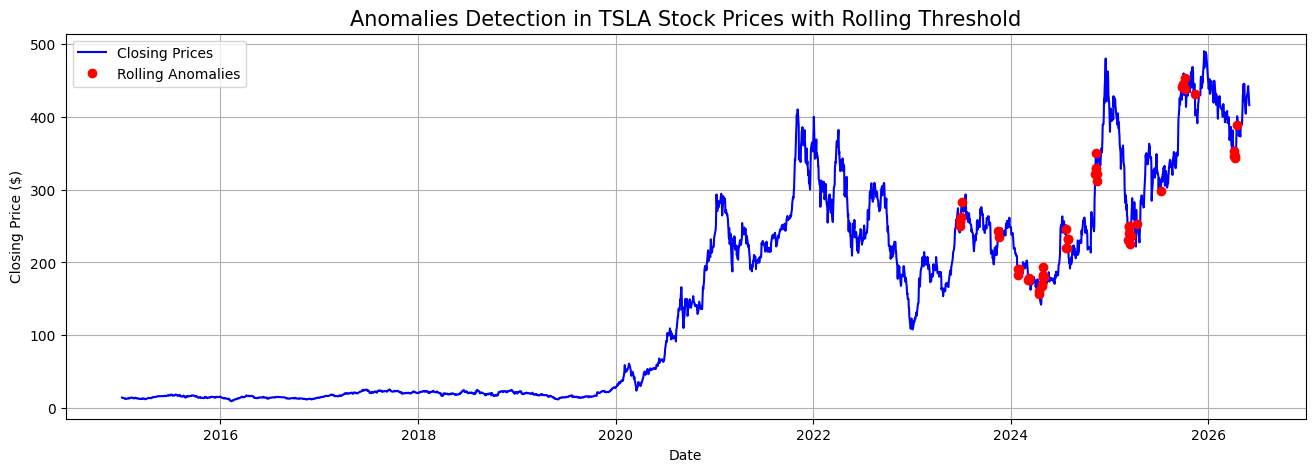

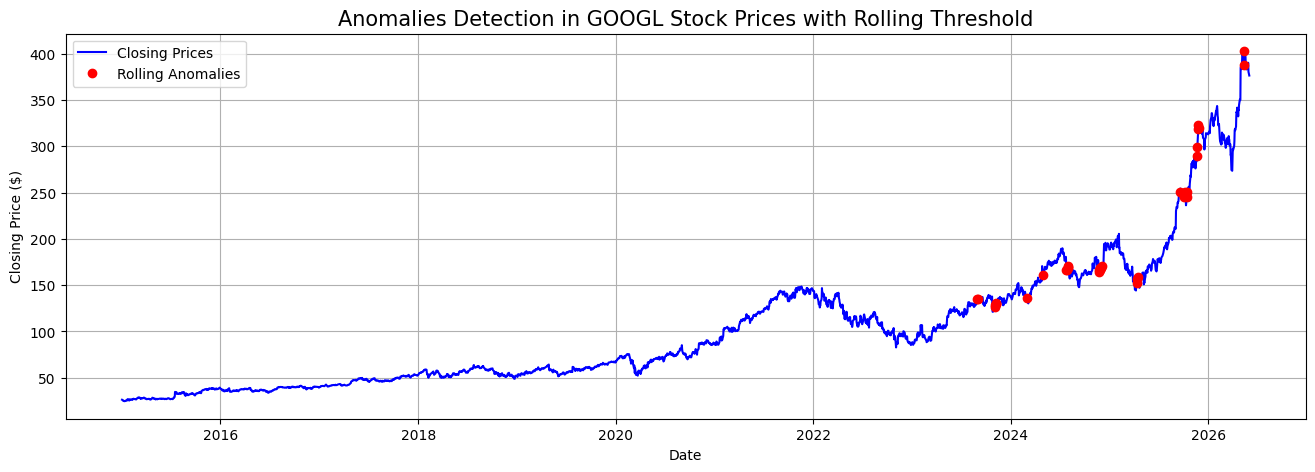

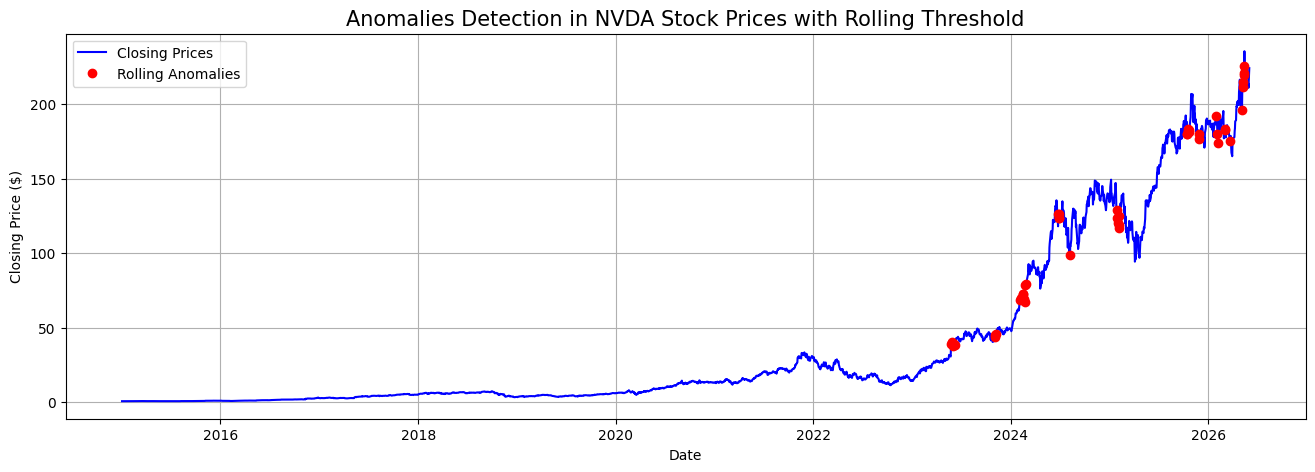

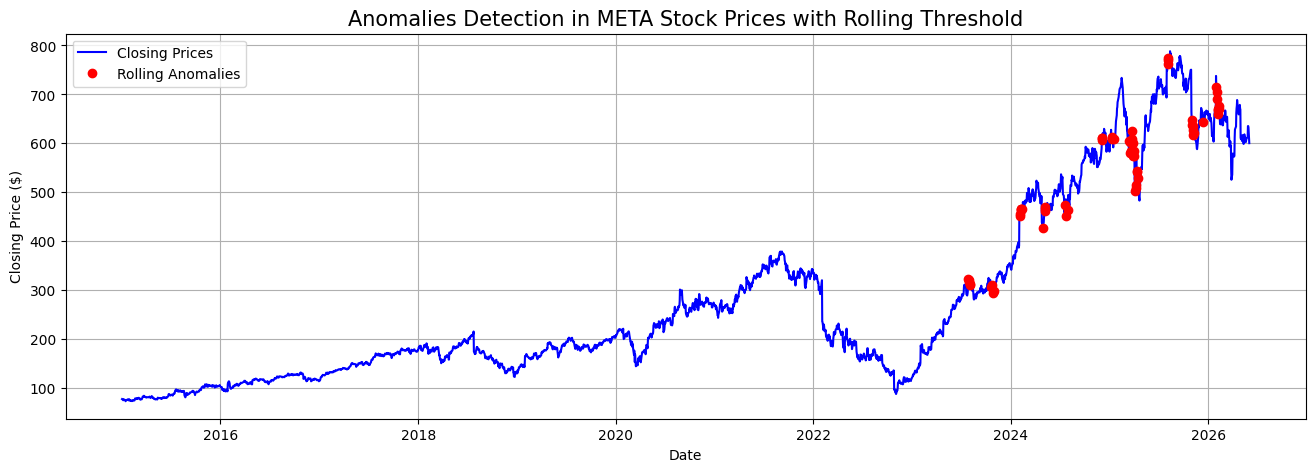

In [ ]:
# plot the price charts with the detection of anomalies (red dots)
for ticker in tickers:
    plt.figure(figsize=(16, 5))

    # Plot the main data points as discrete dots
    plt.plot(df_prices[ticker]['Date'], df_prices[ticker]["Close"], marker='', color='b', linestyle='-', label='Closing Prices')

    # Plot the anomalies as red dots (using the new rolling anomalies)
    plt.plot(rolling_anomalies_for_plot_dict[ticker]['Date'], rolling_anomalies_for_plot_dict[ticker]["Close"], marker='o', color='r', linestyle='', label='Rolling Anomalies')

    # Labels and title
    plt.xlabel("Date")
    plt.ylabel("Closing Price ($)")
    plt.title(f"Anomalies Detection in {ticker} Stock Prices with Rolling Threshold", size=15)

    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
# Interactive price charts and anomalies
import plotly.express as px

for ticker in tickers:
    # Main plot with stock closing prices
    fig = px.line(df_prices[ticker], x="Date", y="Close", title=f"Anomalies Detection in {ticker} Stock Prices with Rolling Threshold",
                  labels={"Date": "Date", "Close": "Closing Price ($)"})

    # Add anomaly points (using the new rolling anomalies)
    fig.add_scatter(x=rolling_anomalies_for_plot_dict[ticker]["Date"], y=rolling_anomalies_for_plot_dict[ticker]["Close"],
                    mode="markers", marker=dict(color='red', size=8),
                    name="Rolling Anomalies")

    # Show grid and legend
    fig.update_layout(
        xaxis_title="Date",
        yaxis_title="Closing Price ($)",
        hovermode="x unified"
    )

    fig.show()

### **(7) Model Evaluation**

I evaluate the model's performance by examining the reconstruction errors and the training process. The distribution of reconstruction Mean Absolute Error (MAE) for the training data typically shows a concentrated set of low errors, indicating the autoencoder has learned to reconstruct 'normal' data effectively. In contrast, the test data's MAE distribution is expected to exhibit a broader range, with higher MAE values for data points identified as anomalies, reflecting the model's difficulty in reconstructing these unusual patterns.

Looking at the training process, a low and stable training loss (blue curve) confirms that the model is successfully learning the underlying patterns of the normal data. The validation loss curve (orange curve), which is typically derived from a portion of the training data during training, might show some fluctuation or be slightly higher than the training loss. If a validation set contains patterns the model finds difficult to reconstruct (analogous to anomalies), its loss would reflect this, indicating the model's ability to identify out-of-distribution instances.

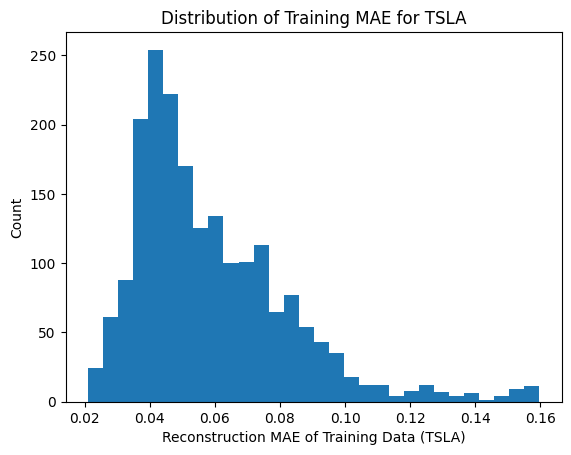

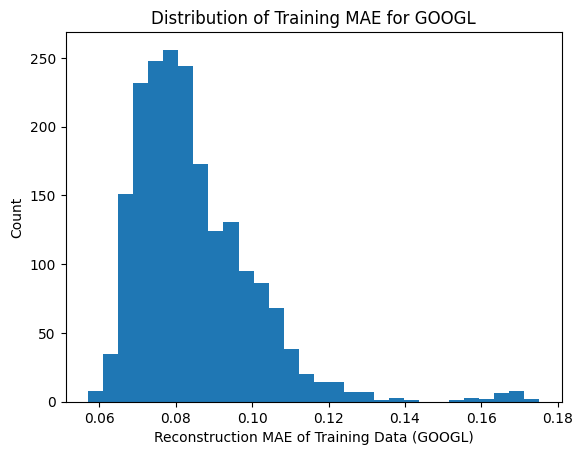

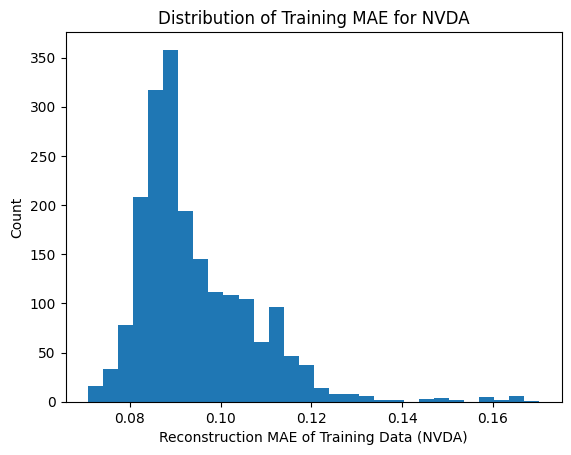

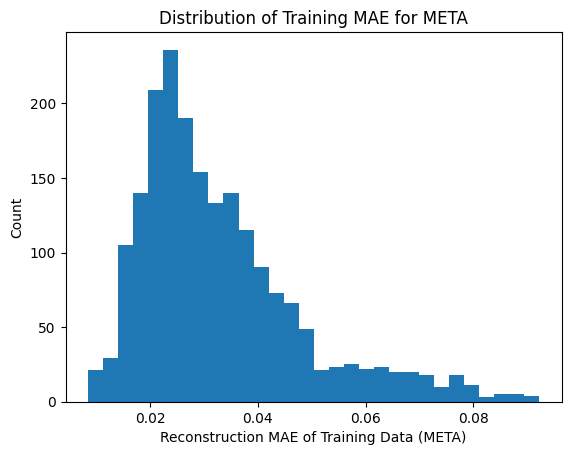

In [ ]:
for ticker in tickers:
    # Plot the distribution of the reconstruction MAE (training data)
    plt.hist(train_mae_loss_dict[ticker], bins=30)
    plt.xlabel(f"Reconstruction MAE of Training Data ({ticker})")
    plt.ylabel("Count")
    plt.title(f"Distribution of Training MAE for {ticker}")
    plt.show()

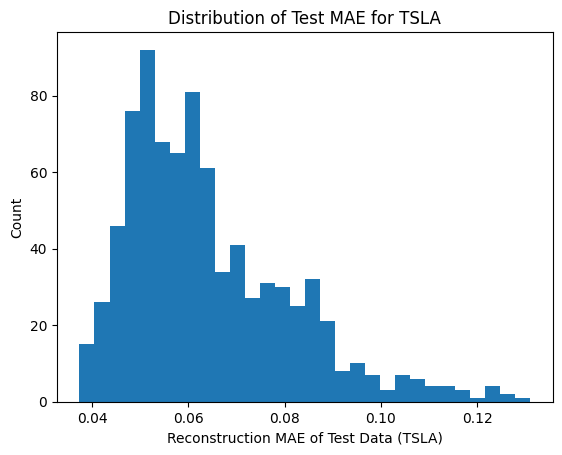

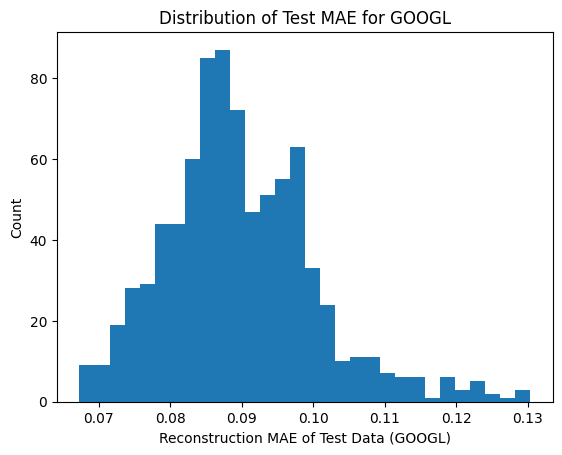

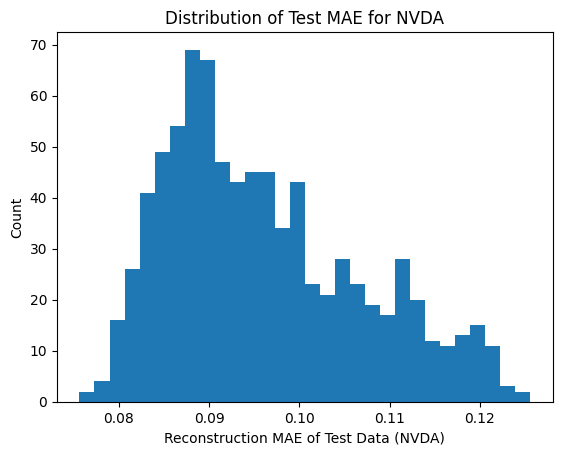

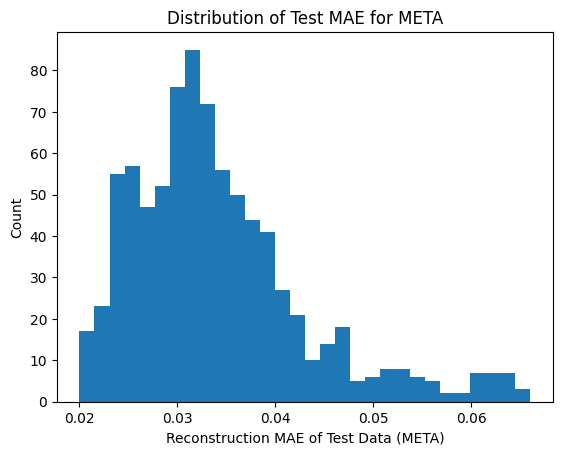

In [ ]:
for ticker in tickers:
    # Plot the distribution of the reconstruction MAE (test data)
    plt.hist(test_mae_loss_dict[ticker], bins=30)
    plt.xlabel(f"Reconstruction MAE of Test Data ({ticker})")
    plt.ylabel("Count")
    plt.title(f"Distribution of Test MAE for {ticker}")
    plt.show()

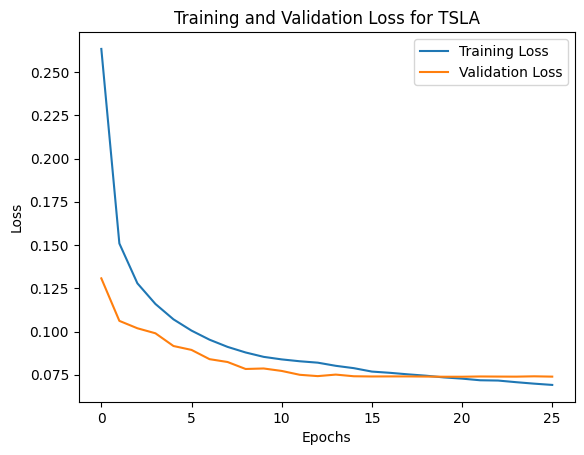

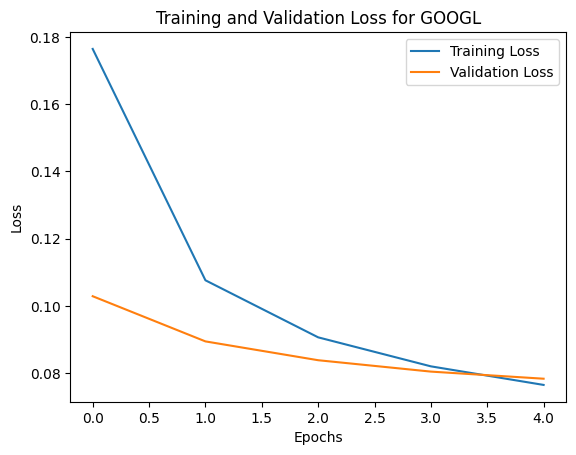

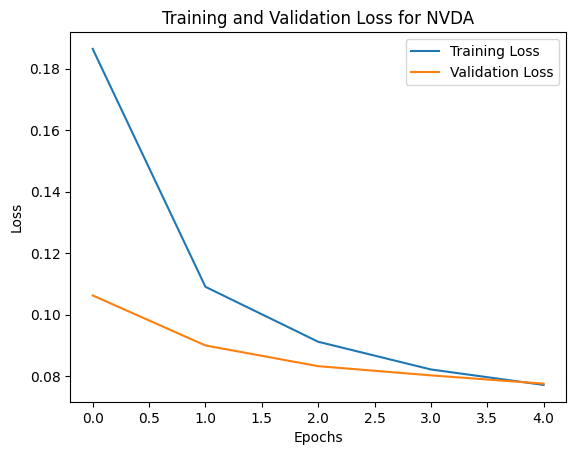

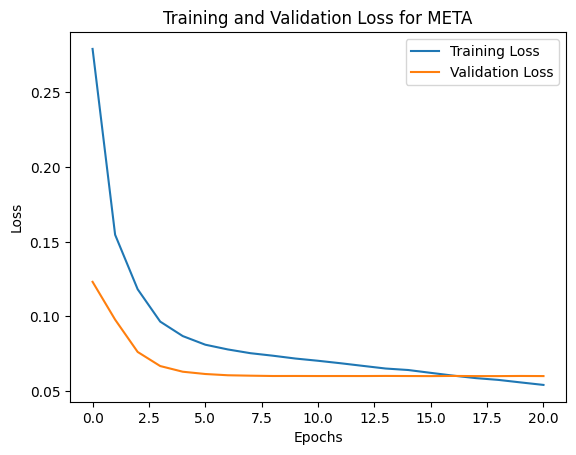

In [ ]:
for ticker in tickers:
    # Plot the graphs of training loss and validation loss
    plt.plot(history_dict[ticker].history['loss'], label='Training Loss')
    plt.plot(history_dict[ticker].history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f"Training and Validation Loss for {ticker}")
    plt.legend()
    plt.show()

### **(8) Save the Models**



In [ ]:
# Save the models in the folder of Colab
for ticker in tickers:
    model_filename = os.path.join('models', f'lstm_autoencoder_{ticker}.keras')
    autoencoders[ticker].save(model_filename)
    print(f"Model for {ticker} saved to {model_filename}")

Model for TSLA saved to models/lstm_autoencoder_TSLA.keras
Model for GOOGL saved to models/lstm_autoencoder_GOOGL.keras
Model for NVDA saved to models/lstm_autoencoder_NVDA.keras
Model for META saved to models/lstm_autoencoder_META.keras


### **(9) Save the Model Artifacts for Deployment**

To deploy this anomaly detection system, besides the trained Keras models, I save the following artifacts:

1.  **`MinMaxScaler` objects**: These are crucial for preprocessing new, unseen data in the same way the training data was scaled.
2.  **`time_step`**: This integer defines the look-back window used to create sequences for the LSTM. It must be consistent between training and deployment.

In [ ]:
# Save the MinMaxScaler for each ticker
for ticker in tickers:
    scaler_filename = os.path.join('scalers', f'minmax_scaler_{ticker}.joblib')
    #joblib.dump(scaler, scaler_filename)
    joblib.dump(scalers[ticker], scaler_filename)
    print(f"MinMaxScaler for {ticker} saved to {scaler_filename}")

# Save the time_step
joblib.dump(time_step, 'time_step.joblib')
print(f"time_step ({time_step}) saved to time_step.joblib")

MinMaxScaler for TSLA saved to scalers/minmax_scaler_TSLA.joblib
MinMaxScaler for GOOGL saved to scalers/minmax_scaler_GOOGL.joblib
MinMaxScaler for NVDA saved to scalers/minmax_scaler_NVDA.joblib
MinMaxScaler for META saved to scalers/minmax_scaler_META.joblib
time_step (30) saved to time_step.joblib


### **(10) Write Results to Google Sheets**

To write data to Google Sheets, need to install the `gspread` library and authenticate Google account. This process allows Colab to access Google Drive and Sheets.

In [ ]:
import gspread
from google.colab import auth
from google.auth import default

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
spreadsheet_id = '1rfEppBM_ZLtF9lIBVo7MW47ZSOVeVZt9U--0pEGwlr8'
sh = gc.open_by_key(spreadsheet_id)

In [ ]:
def update_sheet(df, sheet_name):
    worksheet = sh.worksheet(sheet_name)
    worksheet.clear()
    # Adding header and values
    worksheet.update([df.columns.values.tolist()] + df.astype(str).values.tolist())

gc_anomalies = {}
columns_to_drop = ['Ticker', 'Rolling_Mean_MAE', 'Rolling_Std_MAE']

for ticker, df in rolling_anomaly_dict.items():
    temp_df = df.copy()
    # Drop the specified columns if they exist
    for col in columns_to_drop:
        if col in df.columns:
            temp_df = temp_df.drop(columns=[col])
    gc_anomalies[ticker] = temp_df
    update_sheet(gc_anomalies[ticker], ticker)

print("Success! Google Sheet Updated.")

Success! Google Sheet Updated.
